In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
import math
import numpy as np
import itertools 
from itertools import product
from collections import Counter
import garpar as gp
import re
import skcriteria as skc
from skcriteria import pipelines
from skcriteria.preprocessing import invert_objectives, weighters, scalers
from skcriteria.preprocessing.increment import AddValueToZero
from skcriteria.madm import similarity, moora, electre
from skcriteria.ranksrev import RankInvariantChecker
from garpar.datasets import make_multisector, RissoLevyStable, RissoNormal, RissoUniform
import warnings

/home/nadia/indicador/lib/python3.10/site-packages/skcriteria/madm.py:30: SKCriteriaDeprecationWarning: 'skcriteria.madm' module is deprecated, use 'skcriteria.agg' instead
  utils.deprecate.warn(deprecation_reason)
/home/nadia/indicador/lib/python3.10/site-packages/skcriteria/agg/similarity.py:27: SKCriteriaDeprecationWarning: The module 'skcriteria.agg.similarity' is deprecated since v0.9 and will be removed in v1.0. Please use 'skcriteria.agg.topsis' instead.
  deprecate.warn(


In [2]:
# --- 1. Definición de Nombres (Tickers) ---
nombres_acciones = [
    "CRES", "CADO", "GARO", "INVJ",                                     # AGRO
    "CVH", "TECO2", "AUSO", "BOLT", "CTIO", "DYCA", "GAMI", "GCLA",     # COME (1-8)
    "IRSA", "OEST", "PATA", "POLL", "TGLT",                             # COME (9-13)
    "CEPU", "COME", "EDN", "PAMP", "TGNO4", "TGSU2", "TRAN", "YPFD",    # ENE (1-8)
    "CAPX", "CARC", "CECO2", "CGPA2", "DGCU2", "GBAN", "METR", "MTR",   # ENE (9-16)
    "BBAR", "BMA", "BYMA", "GGAL", "SUPV", "VALO", "BHIP", "BPAT",      # FIN
    "CELU", "GRIM", "HAVA", "INTR", "LEDE", "MOLA", "MOLI", "MORI",     # MOA (1-8)
    "RICH", "SAMI", "SEMI",                                             # MOA (9-11)
    "ALUA", "HARG", "LOMA", "MIRG", "TXAR", "AGRO", "DOME", "FERR",     # MOI (1-8)
    "FIPL", "LONG", "RIGO"                                              # MOI (9-11)
]

In [3]:
# --- 1. Configuración de Parámetros Fijos ---
NUM_ITERACIONES = 200
DIAS_SIMULACION = 40
VENTANAS_A_PROBAR = [3, 5, 7] 

# --- 2. Precios Iniciales (Lista Completa) ---
PRECIOS_INICIALES_TOTAL = [
    1515.00, 475.50, 200.00, 325.00,                      # AGRO (4)
    7000.00, 2490.00, 2725.00, 44.85, 1880.00, 840.00,    # COME (1-6)
    235.75, 2750.00, 2015.00, 710.00, 1300.00, 300.00,    # COME (7-12)
    20.90,                                                # COME (13)
    1655.00, 131.25, 1950.00, 4130.00, 3345.00, 7840.00,  # ENE (1-6)
    2630.00, 45600.00, 5150.00, 29.95, 407.00, 2420.00,   # ENE (7-12)
    1590.00, 1945.00, 2160.00, 2600.00,                   # ENE (13-16)
    7140.00, 9420.00, 206.75, 6870.00, 2830.00, 365.50,   # FIN (1-6)
    419.00, 2265.00,                                      # FIN (7-8)
    311.00, 2150.00, 5900.00, 400.00, 1010.00, 24450.00,  # MOA (1-6)
    3060.00, 224.00, 1500.00, 636.00, 25.55,              # MOA (7-11)
    787.00, 1550.00, 3195.00, 23500.00, 696.00, 49.60,    # MOI (1-6)
    70.00, 25.85, 240.00, 27.00, 670.00                   # MOI (7-11)
]
# --- DEFINICIÓN DE PARÁMETROS INDEPENDIENTES ---
# Mu y Sigma actualizados según el ajuste Normal de 6 meses
# Parámetros con Variabilidad (Sigma) incrementada en un 10%
params_COME = {"alpha": 2.0, "beta": 0.0, "mu": -0.001800171243339, "sigma": 0.020750949918012, "entropy": 0.30}
params_MOA  = {"alpha": 2.0, "beta": 0.0, "mu": -0.003135650006781, "sigma": 0.027947646449187, "entropy": 0.40}
params_MOI  = {"alpha": 2.0, "beta": 0.0, "mu": -0.002459961133639, "sigma": 0.025364664634799, "entropy": 0.40}
params_AGRO = {"alpha": 2.0, "beta": 0.0, "mu": -0.001739865049185, "sigma": 0.026078505925196, "entropy": 0.30}
params_ENE  = {"alpha": 2.0, "beta": 0.0, "mu": -0.001997409088487, "sigma": 0.033038283865323, "entropy": 0.30}
params_FIN  = {"alpha": 2.0, "beta": 0.0, "mu": -0.003414870619394, "sigma": 0.034610600719880, "entropy": 0.40}

# AJUSTE AUTOMÁTICO DE STOCKS_TOTALES
STOCKS_TOTALES = len(PRECIOS_INICIALES_TOTAL) # Esto ahora será 63

# --- 3. Definición de Parámetros (Asegurando 63 entradas) ---
# Usamos multiplicadores para no equivocarnos en la cuenta
parametros_sectores_base = (
    [params_AGRO] * 4 + 
    [params_COME] * 13 + 
    [params_ENE] * 16 + 
    [params_FIN] * 8 + 
    [params_MOA] * 11 + 
    [params_MOI] * 11
)

# Verificación de seguridad
if len(parametros_sectores_base) != STOCKS_TOTALES:
    print(f"ERROR: Tienes {len(parametros_sectores_base)} parámetros pero {STOCKS_TOTALES} precios.")

# --- 4. BUCLE DE SIMULACIÓN ---
resultados_por_ventana = {ventana: [] for ventana in VENTANAS_A_PROBAR}

for VENTANA in VENTANAS_A_PROBAR:
    print(f"Iniciando {NUM_ITERACIONES} simulaciones para Ventana: {VENTANA} días...")
    
    for i in range(NUM_ITERACIONES):
        random_seed_base = i * 10000 
        distribuciones_para_corrida = []
        
        for j, params in enumerate(parametros_sectores_base):
            semilla_sector = random_seed_base + (j * 100)
            params_corrida = params.copy() 
            params_corrida['random_state'] = semilla_sector
            # Se asume que RissoLevyStable está importada correctamente
            distribuciones_para_corrida.append(RissoLevyStable(**params_corrida))

        # SIMULACIÓN DEL MERCADO
        stocksset = make_multisector(
            *distribuciones_para_corrida,
            stocks=STOCKS_TOTALES,  
            days=DIAS_SIMULACION,
            window_size=VENTANA,
            price=PRECIOS_INICIALES_TOTAL 
        )
        
        df_simulacion = stocksset._prices_df 
        resultados_por_ventana[VENTANA].append(df_simulacion)
    
print("\n--- ¡Generación de Simulaciones Finalizada! ---")

Iniciando 200 simulaciones para Ventana: 3 días...
Iniciando 200 simulaciones para Ventana: 5 días...
Iniciando 200 simulaciones para Ventana: 7 días...

--- ¡Generación de Simulaciones Finalizada! ---


In [4]:
# --- 5. Definición de Nombres de Acciones (Fuera del bucle) ---
nombres_acciones = [
    "CRES", "CADO", "GARO", "INVJ",                                     # AGRO
    "CVH", "TECO2", "AUSO", "BOLT", "CTIO", "DYCA", "GAMI", "GCLA",     # COME (1-8)
    "IRSA", "OEST", "PATA", "POLL", "TGLT",                             # COME (9-13)
    "CEPU", "COME", "EDN", "PAMP", "TGNO4", "TGSU2", "TRAN", "YPFD",    # ENE (1-8)
    "CAPX", "CARC", "CECO2", "CGPA2", "DGCU2", "GBAN", "METR", "MTR",   # ENE (9-16)
    "BBAR", "BMA", "BYMA", "GGAL", "SUPV", "VALO", "BHIP", "BPAT",      # FIN
    "CELU", "GRIM", "HAVA", "INTR", "LEDE", "MOLA", "MOLI", "MORI",     # MOA (1-8)
    "RICH", "SAMI", "SEMI",                                             # MOA (9-11)
    "ALUA", "HARG", "LOMA", "MIRG", "TXAR", "AGRO", "DOME", "FERR",     # MOI (1-8)
    "FIPL", "LONG", "RIGO"                                              # MOI (9-11)
]

# --- 6. Ensamblado: Asignación de Nombres a los DataFrames Resultantes ---
# Recorremos el diccionario generado en el paso 4 y renombramos las columnas
for ventana in VENTANAS_A_PROBAR:
    for df in resultados_por_ventana[ventana]:
        # Asignamos los nombres directamente a las columnas del DataFrame
        df.columns = nombres_acciones

print("--- Nombres de acciones integrados correctamente en todos los DataFrames ---")

--- Nombres de acciones integrados correctamente en todos los DataFrames ---


In [5]:
# --- 0. CONFIGURACIÓN INICIAL ---
# Suprimir el warning común de garpar/pypfopt sobre matrices no positivas
warnings.filterwarnings('ignore', category=UserWarning, message='The covariance matrix is non positive semidefinite. Amending eigenvalues.')
warnings.filterwarnings('ignore', category=UserWarning, message="No risk_free_rate specified, coercing it")
# ⚠️ DEFINICIÓN DE LOS OPTIMIZADORES A PROBAR (Asumida)
optimizadores_a_probar = {
   "Sharpe": gp.optimize.mean_variance.MVOptimizer(model='max_sharpe'),
    "Markowitz s.a ret 0.001": gp.optimize.mean_variance.Markowitz(target_return=0.001),
    "Markowitz s.a ret 0.01": gp.optimize.mean_variance.Markowitz(target_return=0.01),
    "Markowitz s.a. riesgo 0.20 ": gp.optimize.mean_variance.Markowitz(target_risk=0.20),
    "Markowitz s.a. riesgo 0.25 ": gp.optimize.mean_variance.Markowitz(target_risk=0.25),
    "Markowitz s.a. riesgo 0.30 ": gp.optimize.mean_variance.Markowitz(target_risk=0.30),


}

rows = []

print("--- INICIO DEL PROCESAMIENTO DE MÉTRICAS (Usando StocksSet) ---")

# --- 1. BUCLE DE PROCESAMIENTO SOBRE LOS RESULTADOS GUARDADOS ---

for VENTANA, lista_simulaciones in resultados_por_ventana.items():
    
    for i, df_corrida in enumerate(lista_simulaciones):
        
        corrida_id = i + 1
        stocks_number_base = len(df_corrida.columns)

        # 💡 MEJORA DE ROBUSTEZ: Intentar crear el StocksSet primero
        stocksset_corrida = None
        try:
            stocksset_corrida = gp.StocksSet.from_prices(df_corrida, window_size=VENTANA)
        except Exception as e:
            # Si el StocksSet falla (ej: datos malformados), registra el fallo para TODOS los modelos
            print(f"⚠️ Error al crear StocksSet (Corrida {corrida_id}, Ventana {VENTANA}): {e}. Saltando modelos.")
            
            for opt_name in optimizadores_a_probar.keys():
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name,
                    "stocks_number": stocks_number_base, 
                    "Cross_Entropy": np.nan,
                    "Zheng_Entropy": np.nan,
                    "Div_Ratio": np.nan,
                    "CV_MC": np.nan,
                    "PDI": np.nan
                })
            continue # Pasa a la siguiente corrida
        
        # 2. ITERACIÓN SOBRE LOS MODELOS DE OPTIMIZACIÓN
        for opt_name, optimizador in optimizadores_a_probar.items():
            
            try:
                # 3. OPTIMIZACIÓN + PRUNING
                mopt = optimizador.optimize(stocksset_corrida).weights_prune()
                
                # 4. CÁLCULO DE MÉTRICAS (EXITOSO)
                metricas = {
                    "stocks_number": len(mopt.stocks),
                    "Cross_Entropy": mopt.div.cross_entropy(),
                    "Zheng_Entropy": mopt.div.zheng_entropy(),
                    "Div_Ratio": mopt.div.ratio(),
                    "CV_MC": (mopt.div.mrc() * mopt.weights).std() / (mopt.div.mrc() * mopt.weights).mean(),
                    "PDI": mopt.div.pdi(n_components=3, random_state=100)
                }

                # 5. GUARDAR RESULTADO EXITOSO
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name, 
                    **metricas
                })

            except Exception as e:
                #  Garantizar que la fila de identificadores se guarde
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name,
                    "stocks_number": stocks_number_base, 
                    "Cross_Entropy": np.nan,
                    "Zheng_Entropy": np.nan,
                    "Div_Ratio": np.nan,
                    "CV_MC": np.nan,
                    "PDI": np.nan
                })
            
# --- 2. CREACIÓN DEL DATAFRAME FINAL ---

df_metricas_simulacion = pd.DataFrame(rows)

# Esta línea ahora es segura, ya que 'rows' garantiza las claves de índice
df_metricas_simulacion = df_metricas_simulacion.set_index(["Ventana", "Corrida", "Modelo_Opt"])

print("\n--- ANÁLISIS COMPLETADO ---")
print(f"Total de resultados guardados: {len(df_metricas_simulacion)} filas.")
print(df_metricas_simulacion.head(9))


--- INICIO DEL PROCESAMIENTO DE MÉTRICAS (Usando StocksSet) ---


/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadi


--- ANÁLISIS COMPLETADO ---
Total de resultados guardados: 3600 filas.
                                             stocks_number  Cross_Entropy  \
Ventana Corrida Modelo_Opt                                                  
3       1       Sharpe                                  34       0.461956   
                Markowitz s.a ret 0.001                 36       0.465002   
                Markowitz s.a ret 0.01                  36       0.465002   
                Markowitz s.a. riesgo 0.20              19       5.276363   
                Markowitz s.a. riesgo 0.25              17       4.353743   
                Markowitz s.a. riesgo 0.30              16       4.578643   
        2       Sharpe                                  31       0.349945   
                Markowitz s.a ret 0.001                 47       2.602706   
                Markowitz s.a ret 0.01                  47       2.603784   

                                             Zheng_Entropy  Div_Ratio  \
Ventana

In [6]:
#Eliminar corridas con NaN ===
# =========================================================================

# 1. Identificar el nivel del índice que representa la "corrida"
LEVEL_CORRIDA = 'Corrida' 

# 2. Inicializar una lista para guardar las corridas (índices) que deben eliminarse
corridas_a_eliminar = set()

# 3. Iterar sobre las corridas (grupos) para verificar NaNs
for corrida_id, group_df in df_metricas_simulacion.groupby(level=LEVEL_CORRIDA):
    
    # 4. Verificar si existe AL MENOS UN NaN en CUALQUIERA de las filas
    # .isnull() crea un DF booleano, .any(axis=None) verifica si hay True en todo el grupo.
    if group_df.isnull().any().any(): 
        # Si se encuentra un NaN, se añade el ID de la corrida a la lista de eliminación
        corridas_a_eliminar.add(corrida_id)

# 5. Filtrar el DataFrame original, excluyendo las corridas identificadas
# Creamos una máscara booleana: True para las corridas que NO están en la lista
mascara_mantener = ~df_metricas_simulacion.index.get_level_values(LEVEL_CORRIDA).isin(corridas_a_eliminar)

# Aplicar la máscara al DataFrame
df_metricas_limpio = df_metricas_simulacion[mascara_mantener]


In [7]:
df_metricas_limpio[df_metricas_limpio.index.get_level_values('Ventana') == 3].describe()

,stocks_number,Cross_Entropy,Zheng_Entropy,Div_Ratio,CV_MC,PDI
count,1140.000000,1140.000000,1140.000000,1.140000e+03,1.140000e+03,1140.000000
mean,24.145614,1.401872,2.483291,1.719088e+05,9.221015e+04,0.555742
std,13.851775,1.623130,0.815382,1.755876e+06,1.115601e+06,0.595189
min,3.000000,0.019413,0.580205,9.045215e-02,5.230217e-01,-0.197282
25%,11.000000,0.383460,1.728287,1.617486e-01,8.773749e-01,0.083761
50%,24.500000,0.559649,2.655374,4.056231e-01,2.448497e+00,0.294303
75%,35.000000,2.004385,3.267850,2.550337e+00,3.787550e+00,0.930208
max,63.000000,9.945080,3.742310,2.723805e+07,2.003118e+07,2.725192


In [8]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 3
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_3 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v3 = df_ventana_3.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v3;


In [9]:
len(corridas_existentes_v3)


190

In [10]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v3:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_3[df_ventana_3.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm



In [11]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    # CAMBIO 1: Se agrega AddValueToZero al inicio para evitar divisiones por cero posteriores
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(), 
)

# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v3:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v3 = pd.concat(resultados_similaridad)
    df_similaridad_total_v3.index.name = 'Corrida'
else:
    df_similaridad_total_v3 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v3

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
1,0.551862,0.677652,0.677652,0.274536,0.344769,0.357493
2,0.490017,0.565949,0.565915,0.465269,0.265660,0.436118
3,0.612617,0.714862,0.714862,0.323992,0.425034,0.270252
4,0.570550,0.639825,0.639825,0.506343,0.305642,0.491957
5,0.564998,0.623657,0.623657,0.527178,0.294392,0.578167
...,...,...,...,...,...,...
196,0.544648,0.641091,0.641091,0.515386,0.478583,0.353846
197,0.462485,0.610756,0.610756,0.249327,0.348095,0.491113
198,0.568254,0.676144,0.676144,0.546589,0.553467,0.375986


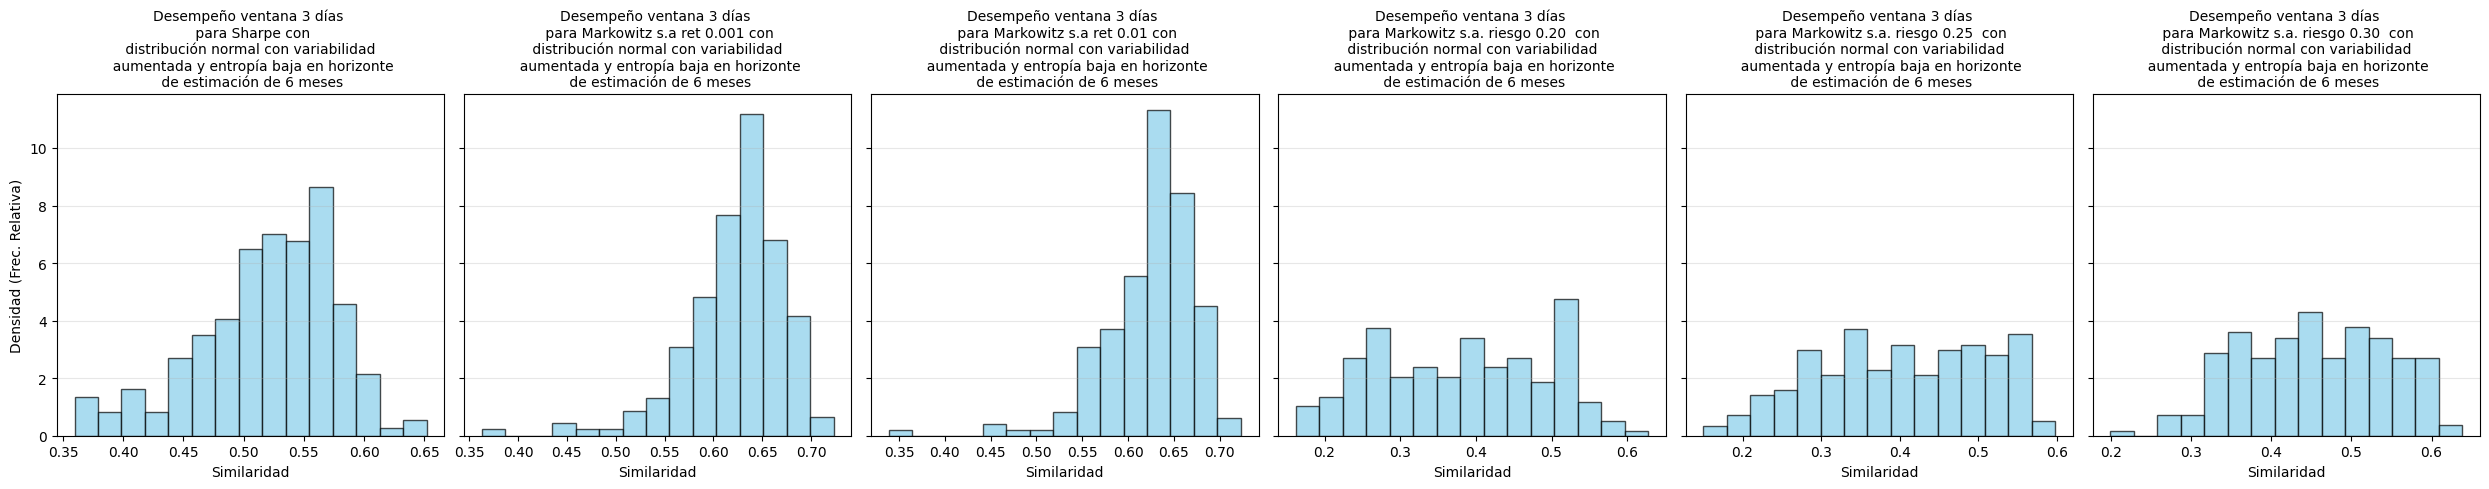

In [12]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v3.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v3[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 3 días \n para {modelo} con\n distribución normal con variabilidad \n  aumentada y entropía baja en horizonte \n de estimación de 6 meses', fontsize=10)

    ax.set_xlabel('Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Ci_hist_v3_mdo+var_be", dpi=300, bbox_inches='tight')

In [13]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 5
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_5 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v5 = df_ventana_5.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v5;


In [14]:
len(corridas_existentes_v5)

190

In [15]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v5:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_5[df_ventana_5.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm


In [16]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(),
)
# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v5:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
   
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v5 = pd.concat(resultados_similaridad)
    df_similaridad_total_v5.index.name = 'Corrida'
else:
    df_similaridad_total_v5 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v5

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
1,0.575345,0.643244,0.643244,0.391118,0.257809,0.544551
2,0.523241,0.611499,0.611499,0.288285,0.362452,0.557192
3,0.510728,0.654927,0.654927,0.350290,0.477341,0.380713
4,0.539725,0.624812,0.624812,0.344486,0.410372,0.385288
5,0.559735,0.626081,0.626081,0.297321,0.523665,0.483336
...,...,...,...,...,...,...
196,0.491944,0.484049,0.480785,0.514188,0.529854,0.507729
197,0.499102,0.657853,0.657853,0.238479,0.480470,0.479801
198,0.498598,0.635948,0.635948,0.283487,0.258205,0.403151


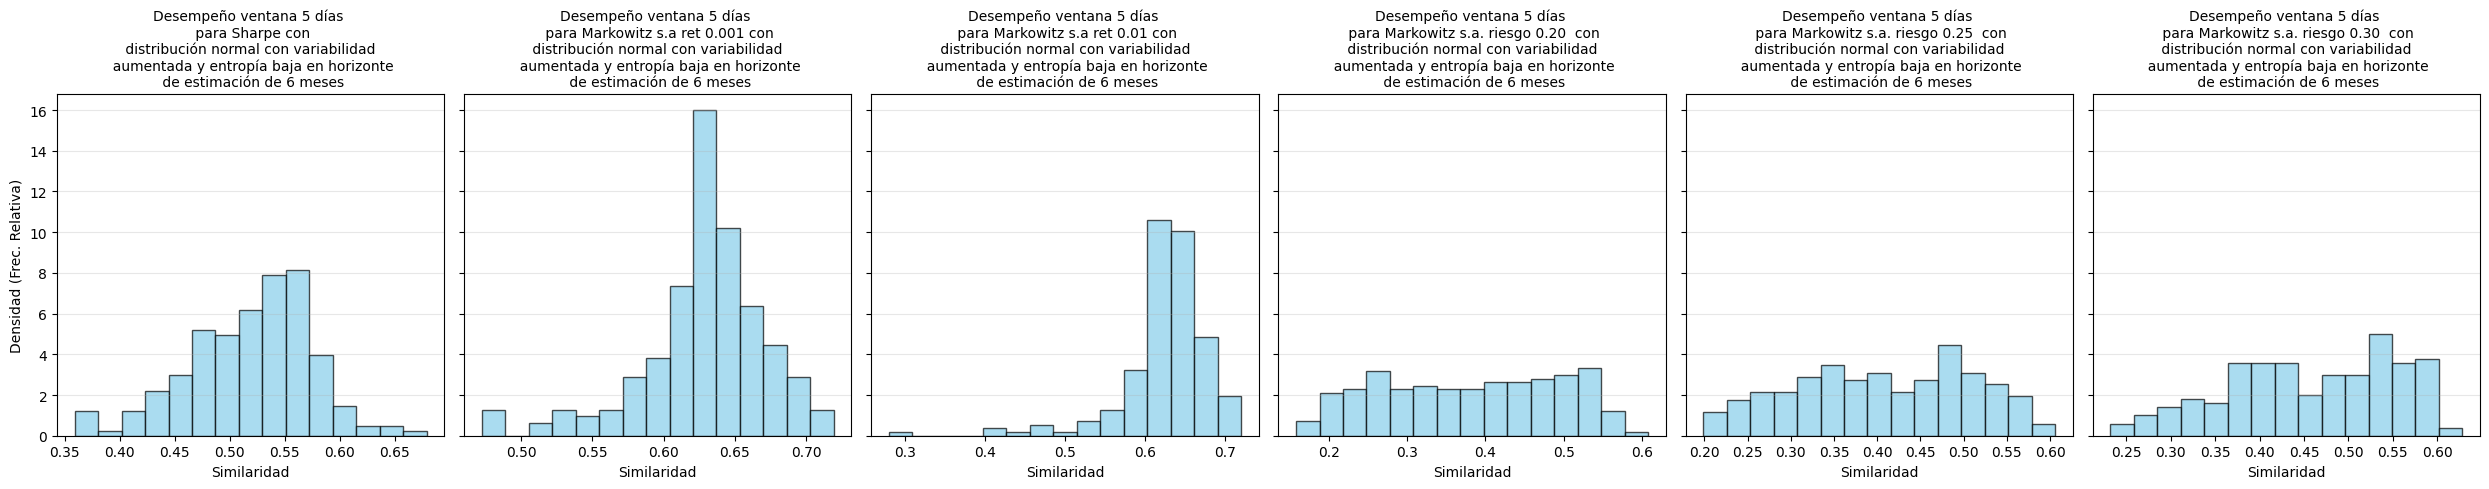

In [17]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v5.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v5[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 5 días \n para {modelo} con\n distribución normal con variabilidad \n  aumentada y entropía baja en horizonte \n de estimación de 6 meses', fontsize=10)

    ax.set_xlabel('Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Ci_hist_v5_mdo+var_be", dpi=300, bbox_inches='tight')

In [18]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 7
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_7 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v7 = df_ventana_7.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v7;

In [19]:
len(corridas_existentes_v7)

190

In [20]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v7:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_7[df_ventana_7.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm


In [21]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(),
)
# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v7:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
   
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v7 = pd.concat(resultados_similaridad)
    df_similaridad_total_v7.index.name = 'Corrida'
else:
    df_similaridad_total_v7 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v7

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
1,0.573381,0.690318,0.690318,0.517982,0.341086,0.444451
2,0.566148,0.635205,0.635205,0.361081,0.265582,0.573231
3,0.561961,0.676907,0.676907,0.333643,0.307175,0.370813
4,0.472613,0.617962,0.617962,0.216535,0.385606,0.506201
5,0.468027,0.583500,0.580543,0.274708,0.445172,0.447800
...,...,...,...,...,...,...
196,0.548974,0.648173,0.648173,0.511960,0.478512,0.348176
197,0.567083,0.651630,0.651630,0.514192,0.501679,0.363628
198,0.548235,0.686596,0.686596,0.440507,0.346603,0.329951


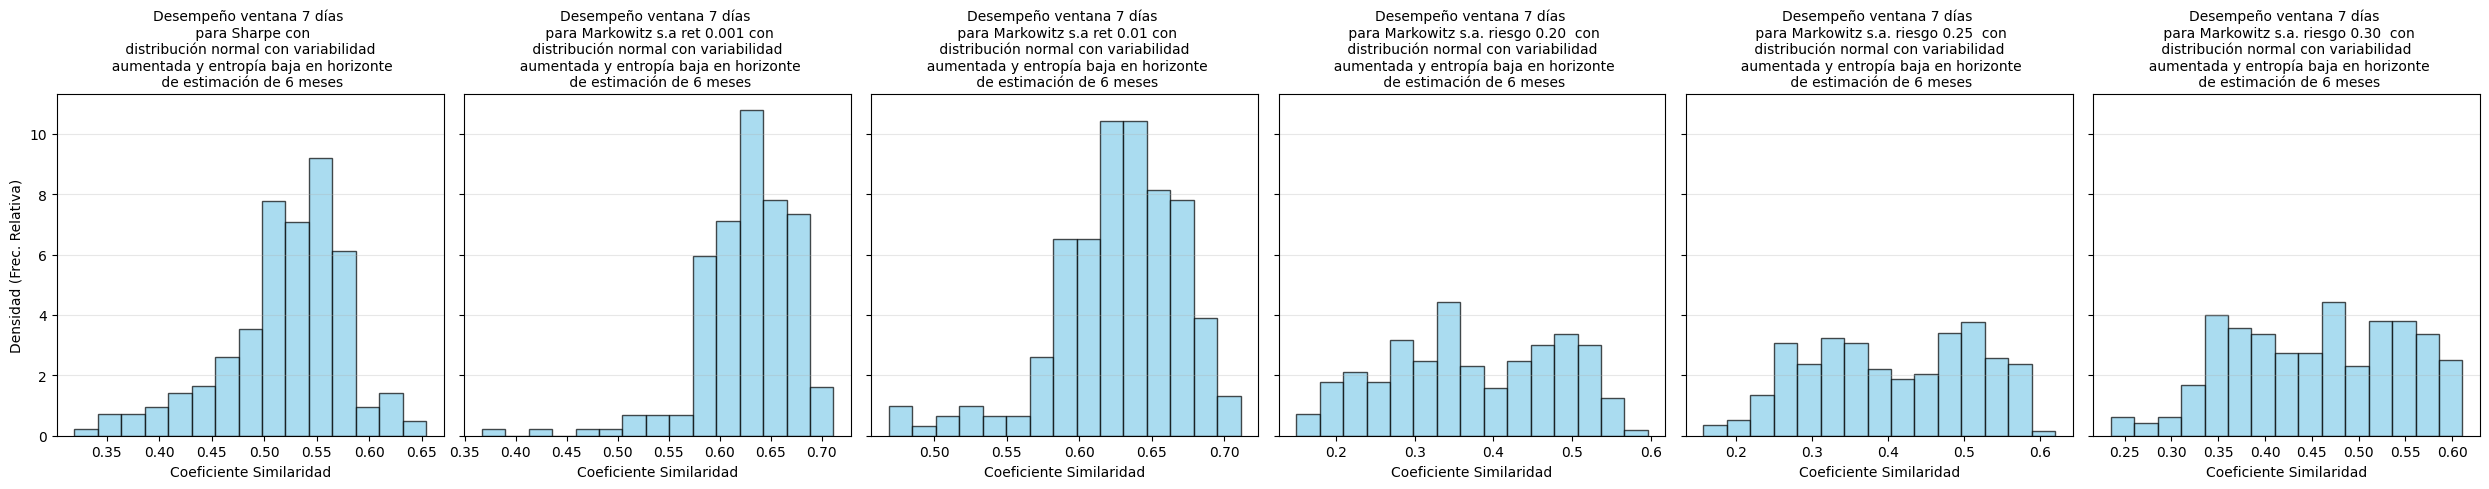

In [22]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v7.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v7[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 7 días \n para {modelo} con\n distribución normal con variabilidad \n  aumentada y entropía baja en horizonte \n de estimación de 6 meses', fontsize=10)

    ax.set_xlabel('Coeficiente Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Ci_hist_v7_mdo+var_be", dpi=300, bbox_inches='tight')

/tmp/ipykernel_27075/2300082951.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_similaridad_total_v3.columns, rotation=90)
/tmp/ipykernel_27075/2300082951.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_similaridad_total_v5.columns, rotation=90)
/tmp/ipykernel_27075/2300082951.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(df_similaridad_total_v7.columns, rotation=90)


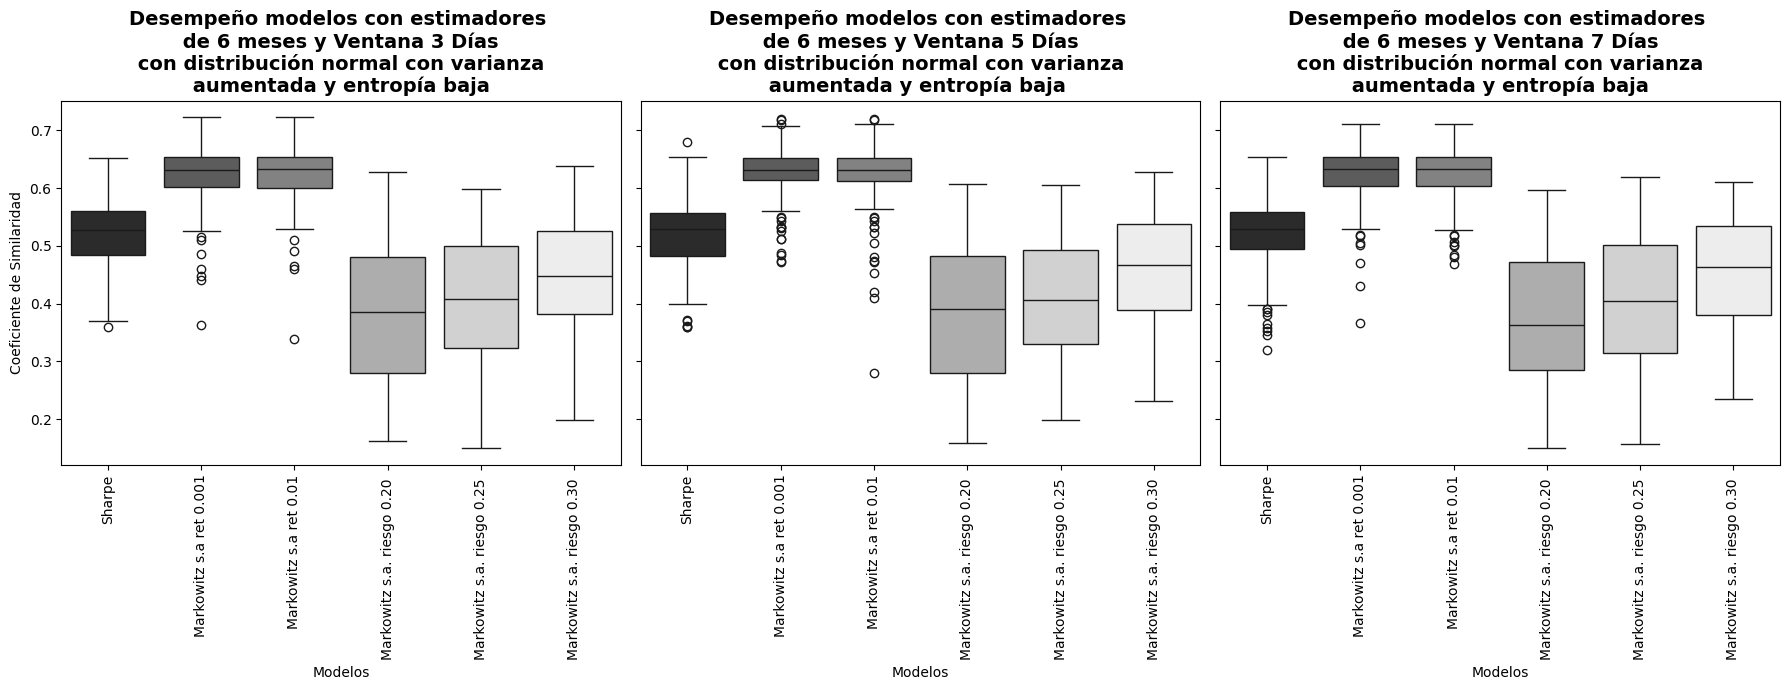

In [23]:
# 1. Configuración de la figura: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# 2. Gráfico 1: Ventana 3 días
sns.boxplot(
    data=df_similaridad_total_v3, 
    ax=axes[0], 
    palette="Greys_r"
)
axes[0].set_title('Desempeño modelos con estimadores \n de 6 meses y Ventana 3 Días \n con distribución normal con varianza \n aumentada y entropía baja ', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(df_similaridad_total_v3.columns, rotation=90)
axes[0].set_ylabel('Coeficiente de Similaridad')
axes[0].set_xlabel('Modelos')

# 3. Gráfico 2: Ventana 5 días
sns.boxplot(
    data=df_similaridad_total_v5, 
    ax=axes[1], 
    palette="Greys_r"
)
axes[1].set_title('Desempeño modelos con estimadores \n de 6 meses y Ventana 5 Días \n con distribución normal con varianza \n aumentada y entropía baja  ', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(df_similaridad_total_v5.columns, rotation=90)
axes[1].set_ylabel('') # Quitamos el label porque comparten eje Y
axes[1].set_xlabel('Modelos')

# 3. Gráfico 3: Ventana 5 días
sns.boxplot(
    data=df_similaridad_total_v7, 
    ax=axes[2], 
    palette="Greys_r"
)
axes[2].set_title('Desempeño modelos con estimadores \n de 6 meses y Ventana 7 Días \n con distribución normal con varianza \n aumentada y entropía baja ', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(df_similaridad_total_v7.columns, rotation=90)
axes[2].set_ylabel('') # Quitamos el label porque comparten eje Y
axes[2].set_xlabel('Modelos')


# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Ci_box_comp_v_mdo+var_be", dpi=300, bbox_inches='tight')

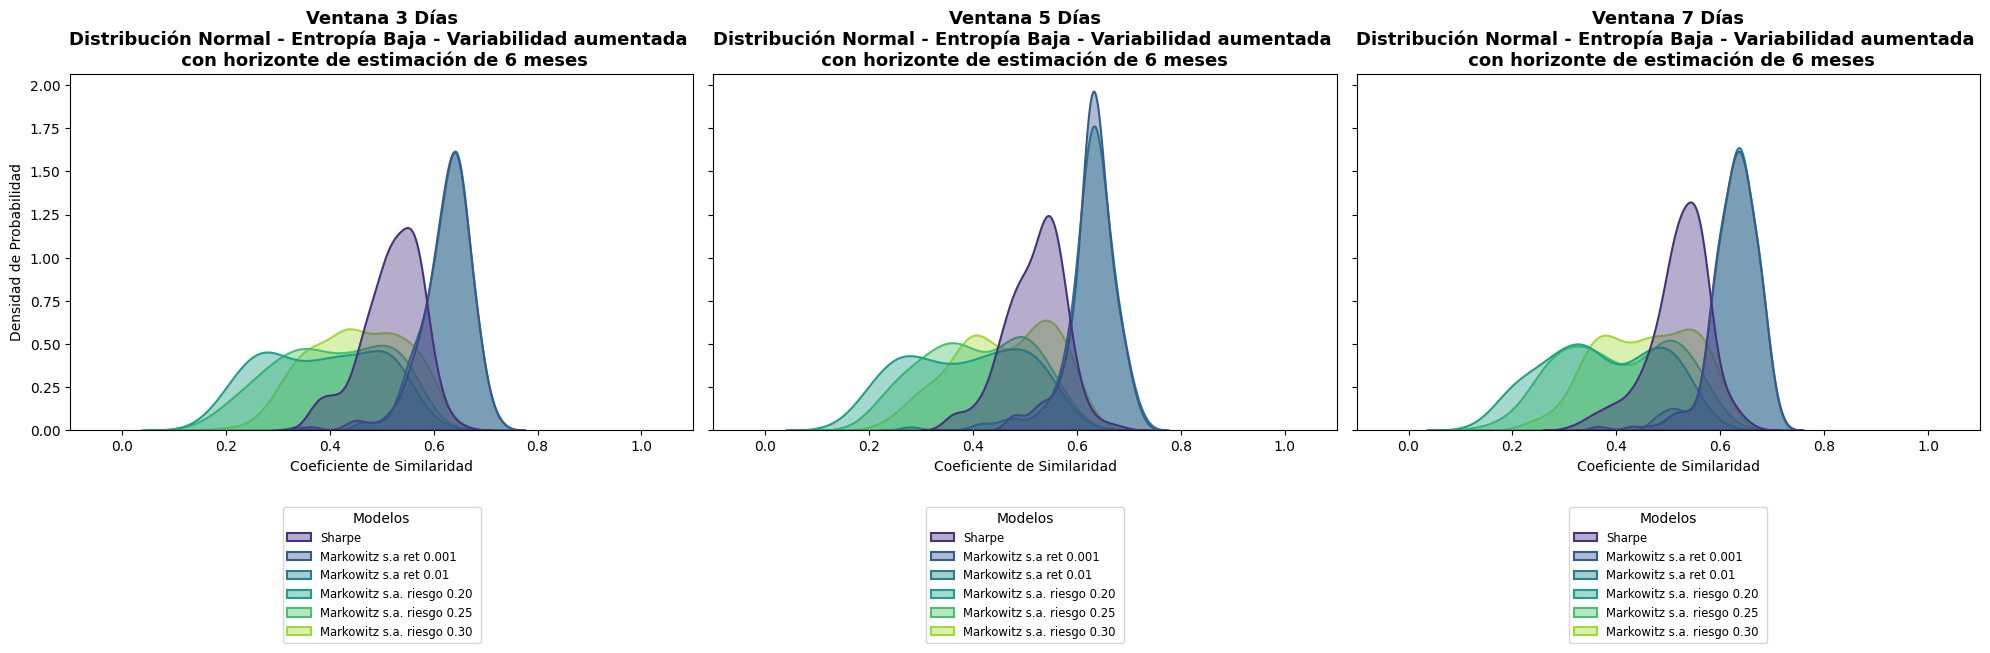

In [24]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    'Ventana 3 Días\nDistribución Normal - Entropía Baja - Variabilidad aumentada \n con horizonte de estimación de 6 meses',
    'Ventana 5 Días\nDistribución Normal - Entropía Baja - Variabilidad aumentada \n con horizonte de estimación de 6 meses ',
    'Ventana 7 Días\nDistribución Normal - Entropía Baja - Variabilidad aumentada \n con horizonte de estimación de 6 meses'
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        fill=True,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    # --- AJUSTE DE EJES ---
    axes[i].set_xlim(-0.10, 1.1) # Fija el rango del eje X
    # ----------------------
    
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Ci_kde_comp_v_mdo+var_be", dpi=300, bbox_inches='tight')

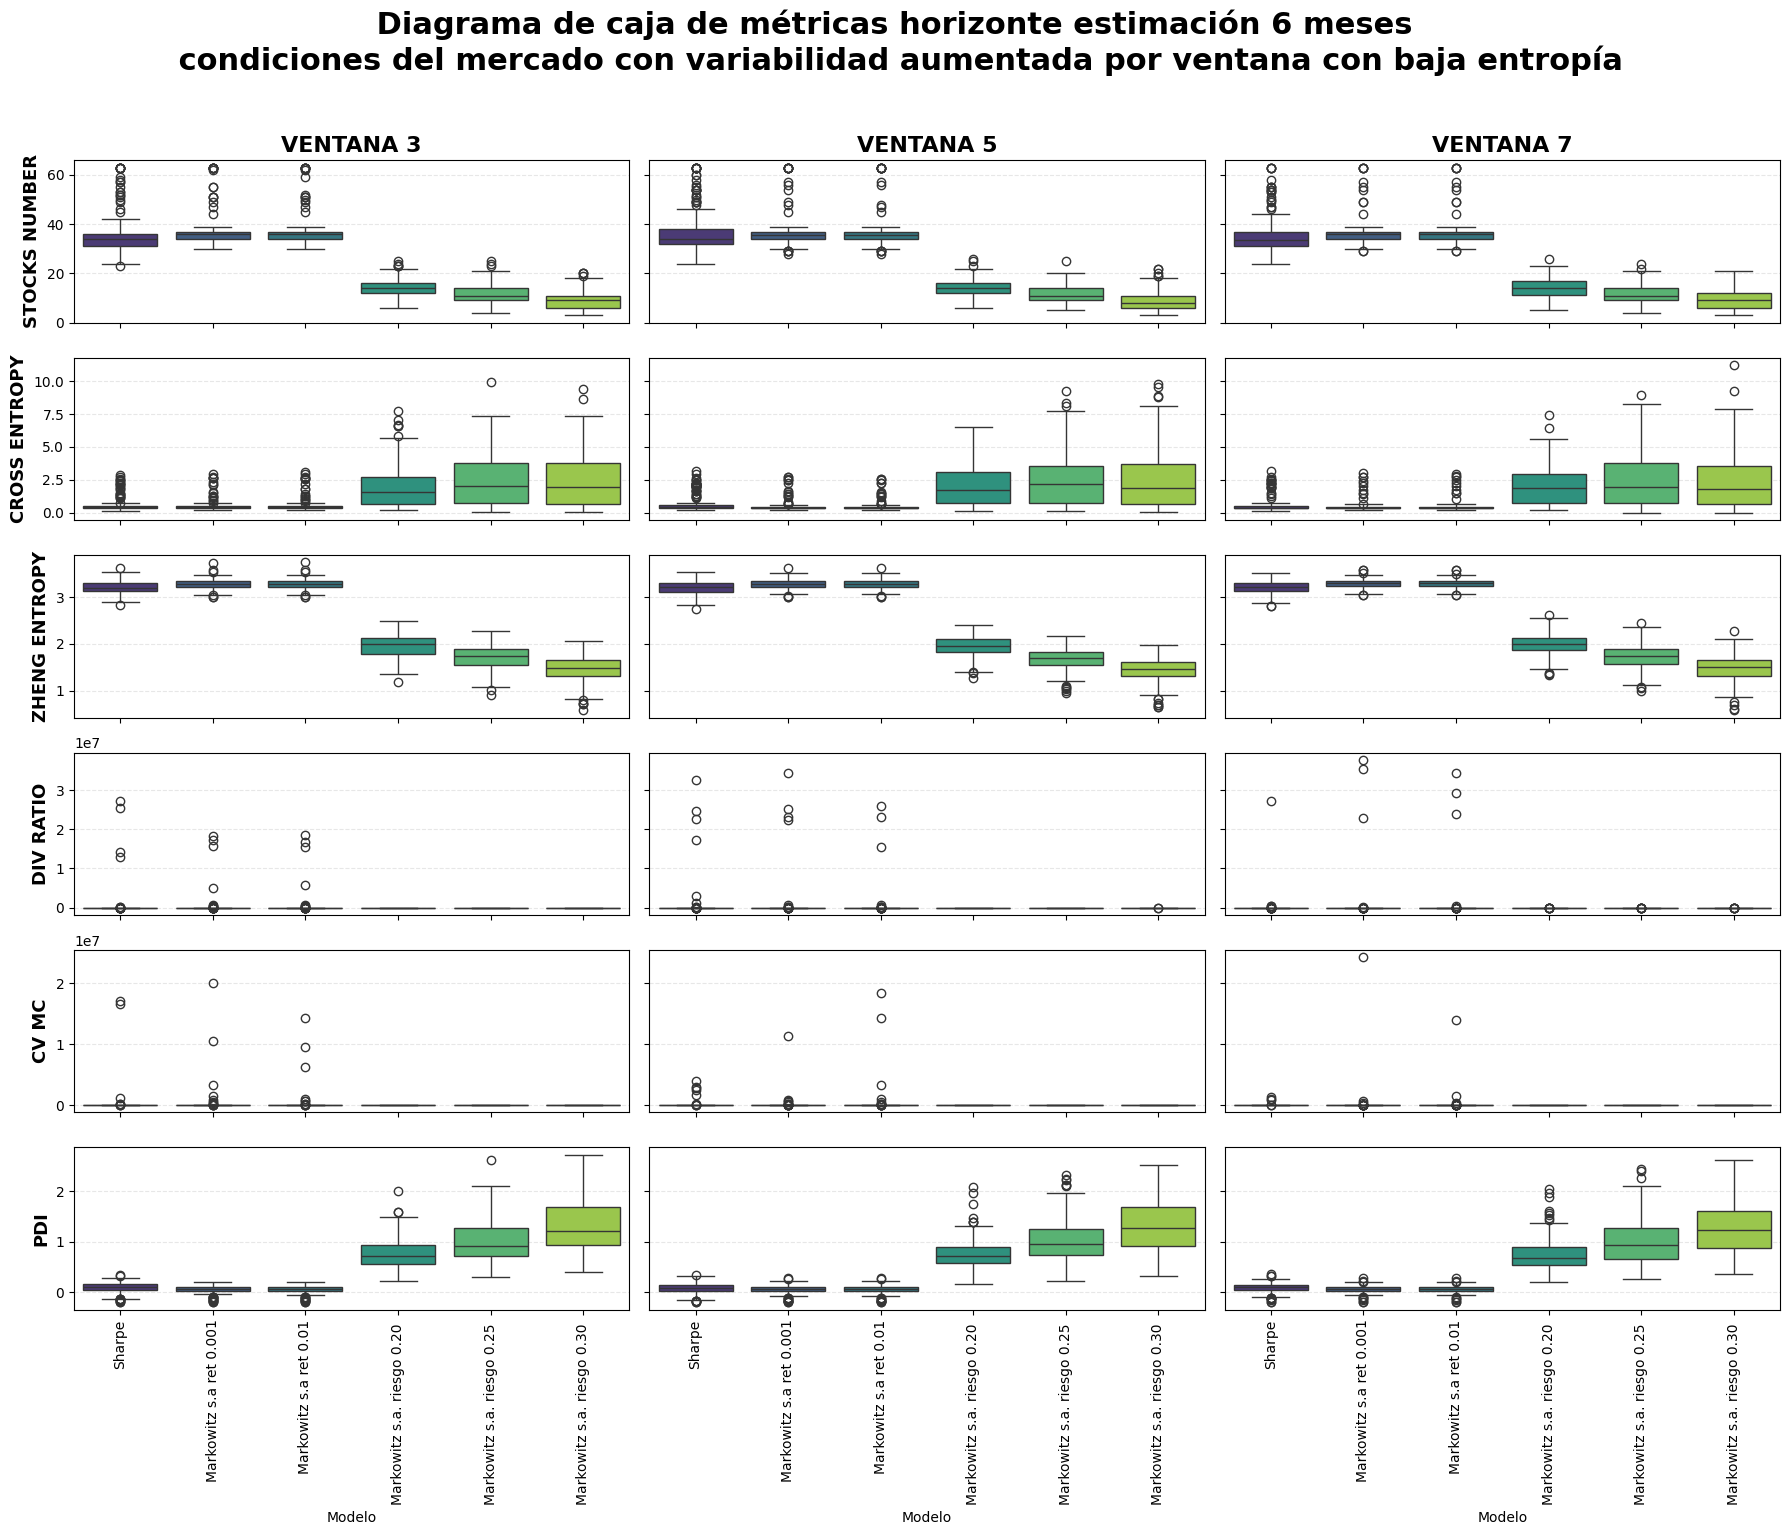

In [25]:
# Silenciamos advertencias para una salida limpia
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Configuración de parámetros y métricas
metricas = ['stocks_number', 'Cross_Entropy', 'Zheng_Entropy', 'Div_Ratio', 'CV_MC', 'PDI']
ventanas_deseadas = [3, 5, 7] 
ventanas_presentes = [v for v in ventanas_deseadas if v in df_metricas_limpio.index.get_level_values('Ventana')]

# 2. Crear la grilla con SHAREY por FILA (métrica) y SHAREX global
# Usamos sharey='row' para que la escala sea comparable entre ventanas para una misma métrica
fig, axes = plt.subplots(nrows=len(metricas), ncols=len(ventanas_presentes), 
                         figsize=(6 * len(ventanas_presentes), 2.5 * len(metricas)), 
                         sharex=True, sharey='row')

fig.suptitle(' Diagrama de caja de métricas horizonte estimación 6 meses \n condiciones del mercado con variabilidad aumentada por ventana con baja entropía', fontsize=22, fontweight='bold', y=1.02)

# 3. Bucle doble: Métrica (Fila) e itera por Ventana (Columna)
for i, col in enumerate(metricas):
    for j, ventana in enumerate(ventanas_presentes):
        ax = axes[i, j]
        
        # Filtramos la ventana actual del DataFrame original
        df_ventana = df_metricas_limpio.xs(ventana, level='Ventana').reset_index()
        
        # Graficamos con corrección de FutureWarning
        sns.boxplot(
            data=df_ventana, 
            x='Modelo_Opt', 
            y=col, 
            ax=ax, 
            palette='viridis', 
            hue='Modelo_Opt',
            legend=False
        )
        
        # Estética de Encabezados (solo primera fila)
        if i == 0:
            ax.set_title(f'VENTANA {ventana}', fontsize=16, fontweight='bold')
        
        # Estética de Etiquetas (solo primera columna para evitar redundancia con sharey)
        if j == 0:
            ax.set_ylabel(col.replace('_', ' ').upper(), fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # Etiquetas de modelos (solo última fila)
        if i == len(metricas) - 1:
            ax.tick_params(axis='x', rotation=90)
            ax.set_xlabel('Modelo')
        else:
            ax.set_xlabel('')

        ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# 4. Ajuste final
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Criteria_box_comp_v_mdo+var_be", dpi=300, bbox_inches='tight')

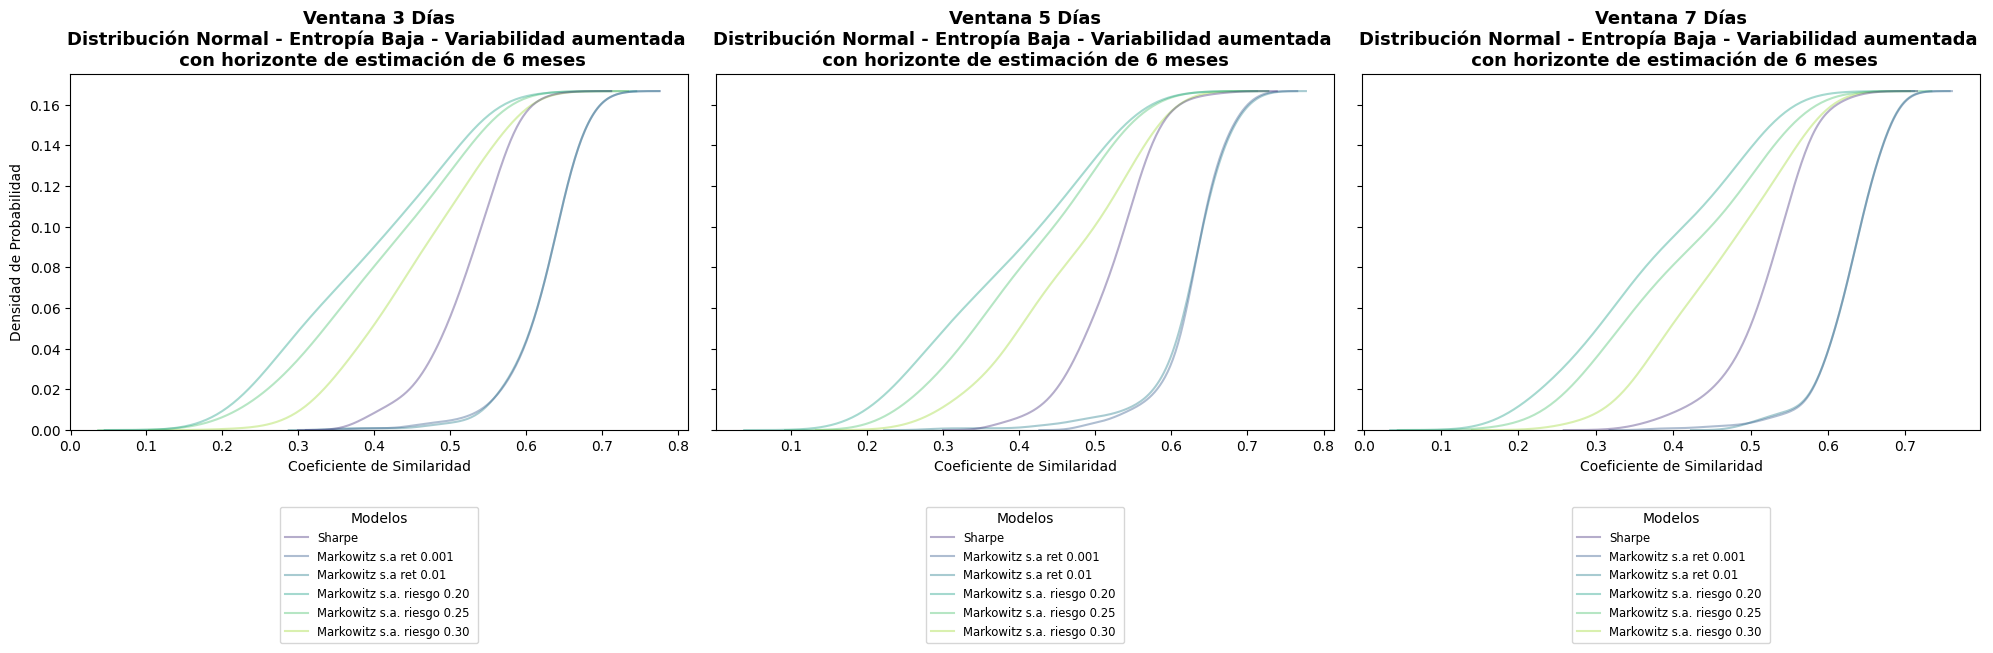

In [26]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    'Ventana 3 Días\nDistribución Normal - Entropía Baja - Variabilidad aumentada \n con horizonte de estimación de 6 meses',
    'Ventana 5 Días\nDistribución Normal - Entropía Baja - Variabilidad aumentada \n con horizonte de estimación de 6 meses ',
    'Ventana 7 Días\nDistribución Normal - Entropía Baja - Variabilidad aumentada \n con horizonte de estimación de 6 meses'
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        cumulative=True,
        fill=False,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/11norm_Ci_ojiva_comp_v_mdo+var_be", dpi=300, bbox_inches='tight')

In [27]:
v7similar_describe = df_similaridad_total_v7.describe()
kurtosis_values = df_similaridad_total_v7.kurt()
v7similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v7.skew()
v7similar_describe.loc["skew"] = skew_values
v7similar_describe.to_csv("dfdescribe_results/11norm_v7similar_describe_mdo+var_be", index=True, sep=',', encoding='utf-8')
v7similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,0.519933,0.626774,0.627136,0.374051,0.405430,0.455847
std,0.057824,0.046571,0.043725,0.109677,0.107968,0.090680
min,0.319305,0.366850,0.468958,0.149569,0.157535,0.235226
25%,0.493871,0.603725,0.603725,0.284687,0.314130,0.379669
50%,0.528888,0.633181,0.633181,0.363737,0.404521,0.464087
75%,0.559526,0.654809,0.654860,0.471612,0.501753,0.534820
max,0.654344,0.711346,0.711346,0.596200,0.620206,0.610806
kurt,1.169450,6.346865,1.749000,-1.125547,-1.137288,-0.950378
skew,-0.891590,-1.740535,-1.040111,-0.065229,-0.086830,-0.194067


In [28]:
v5similar_describe = df_similaridad_total_v5.describe()
kurtosis_values = df_similaridad_total_v5.kurt()
v5similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v5.skew()
v5similar_describe.loc["skew"] = skew_values
v5similar_describe.to_csv("dfdescribe_results/11norm_v5similar_describe_md+var_be", index=True, sep=',', encoding='utf-8')
v5similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,0.518673,0.628356,0.624846,0.382466,0.406918,0.458734
std,0.056357,0.043691,0.054609,0.113672,0.101320,0.094331
min,0.359051,0.472351,0.279810,0.157973,0.198707,0.231841
25%,0.483394,0.613397,0.611613,0.279393,0.329370,0.389678
50%,0.529024,0.631579,0.631147,0.390288,0.406875,0.467601
75%,0.556750,0.652187,0.652187,0.482058,0.492217,0.538091
max,0.679229,0.719415,0.719415,0.607793,0.606080,0.628238
kurt,0.464020,2.163174,10.266283,-1.189956,-1.034083,-0.897328
skew,-0.452376,-1.051603,-2.394715,-0.074286,-0.117752,-0.315521


In [29]:
v3similar_describe = df_similaridad_total_v3.describe()
kurtosis_values = df_similaridad_total_v3.kurt()
v3similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v3.skew()
v3similar_describe.loc["skew"] = skew_values
v3similar_describe.to_csv("dfdescribe_results/11norm_v3similar_describe_mdo+var_be", index=True, sep=',', encoding='utf-8')
v3similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,0.519150,0.623390,0.623835,0.381714,0.402574,0.452906
std,0.057188,0.050337,0.049163,0.111586,0.107872,0.090813
min,0.359571,0.362739,0.338965,0.162265,0.149824,0.198978
25%,0.483906,0.601502,0.600906,0.279336,0.323596,0.382185
50%,0.527406,0.631936,0.632528,0.385813,0.408242,0.447949
75%,0.561315,0.653886,0.653886,0.481256,0.499537,0.526679
max,0.651851,0.723150,0.723150,0.627589,0.598107,0.638505
kurt,0.202146,4.728554,5.957969,-1.174386,-0.966217,-0.811792
skew,-0.663836,-1.574410,-1.607749,-0.031044,-0.196579,-0.163017
